In [18]:
import sys
sys.path.append("..")

from utils import *

df = pd.read_parquet("../data/raw_data.parquet")

os.makedirs("../plots", exist_ok=True)

---
## Exploratory Data Analysis (EDA)

In [19]:
print('\n--- Missing Values: ---')
print(f"{df.isnull().sum()}")
print('\n--- Duplicates: ---')
print(f"{df.duplicated().sum()}")

df['review_length'] = df['text'].apply(len)
df['word_count'] = df['text'].apply(lambda x: len(x.split()))
df['avg_word_length'] = df['review_length'] / df['word_count']

print('\n--- Statitics summary: ---')
print(df[['rating', 'review_length', 'word_count', 'avg_word_length']].describe())
print("\n--- Distribution by Split & Sentiment ---")
print(df.groupby(['split', 'sentiment']).size().unstack(fill_value=0))
print("\n--- Rating Distribution ---")
print(df['rating'].value_counts().sort_index())


--- Missing Values: ---
review_id              0
split                  0
rating                 0
text                   0
sentiment              0
sentiment_label        0
movie_id           50000
dtype: int64

--- Duplicates: ---
0

--- Statitics summary: ---
             rating  review_length    word_count  avg_word_length
count  50000.000000   50000.000000  50000.000000     50000.000000
mean       5.495340    1309.431020    231.156940         5.634164
std        3.478721     989.728014    171.343997         0.340905
min        1.000000      32.000000      4.000000         2.236486
25%        2.000000     699.000000    126.000000         5.411392
50%        5.500000     970.000000    173.000000         5.620934
75%        9.000000    1590.250000    280.000000         5.841730
max       10.000000   13704.000000   2470.000000        13.272727

--- Distribution by Split & Sentiment ---
sentiment    neg    pos
split                  
test       12500  12500
train      12500  12500

--

/tmp/ipykernel_19126/1422587737.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='sentiment', y='word_count',


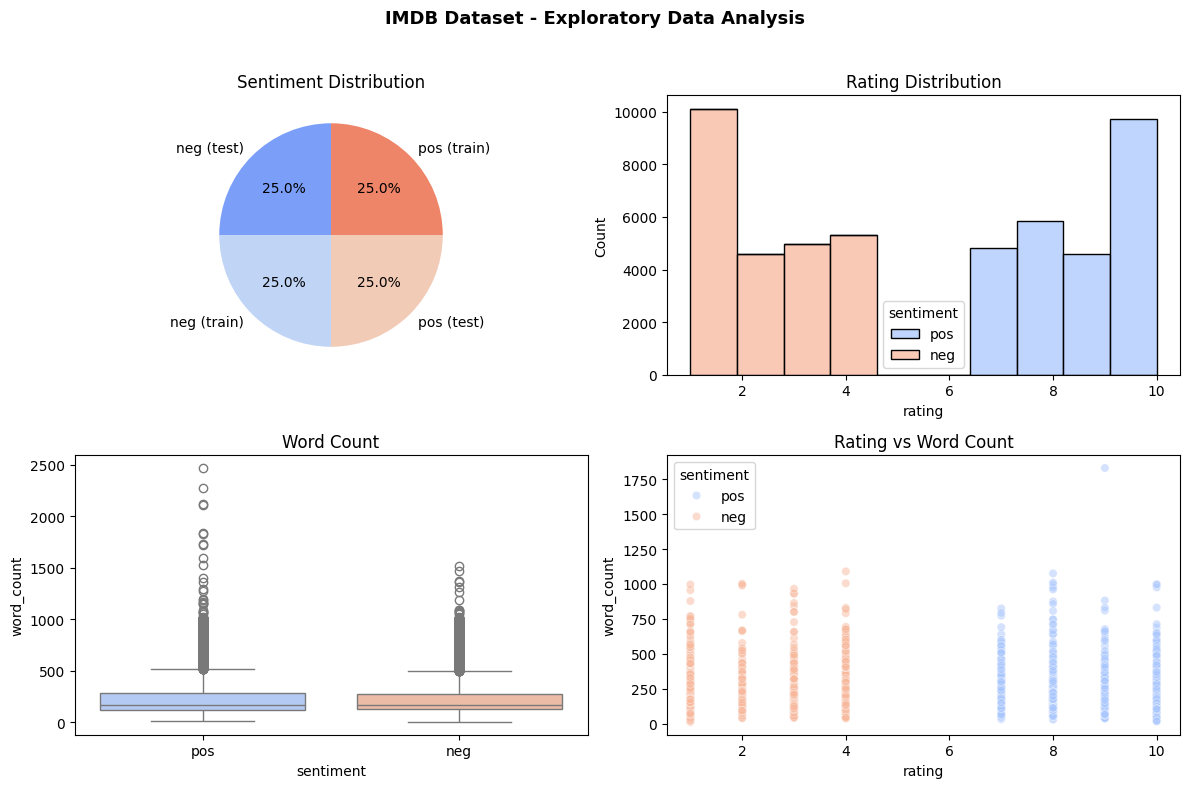

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('IMDB Dataset - Exploratory Data Analysis', fontsize=13, fontweight='bold')

palette = sns.color_palette("coolwarm", 2)
counts = df.groupby(['sentiment','split']).size()
labels = [f"{s} ({sp})" for s, sp in counts.index]

# Plot 1: Sentiment distribution
axes[0,0].pie(counts, labels=labels, autopct='%1.1f%%', startangle=90,
              colors=sns.color_palette("coolwarm", len(counts)))
axes[0,0].set_title('Sentiment Distribution')

# Plot 2: Rating distribution
sns.histplot(data=df, x='rating', hue='sentiment', multiple='stack',
             ax=axes[0,1], palette=palette, bins=10)
axes[0,1].set_title('Rating Distribution')

# Plot 3: Boxplot - Word count by sentiment
sns.boxplot(data=df, x='sentiment', y='word_count',
            ax=axes[1,0], palette=palette)
axes[1,0].set_title('Word Count')

# Plot 4: Scatter - Rating vs Word count
sample = df.sample(n=2000, random_state=42)
sns.scatterplot(data=sample, x='rating', y='word_count',
                hue='sentiment', alpha=0.5,
                ax=axes[1,1], palette=palette)
axes[1,1].set_title('Rating vs Word Count')

plt.tight_layout(rect=[0,0,1,0.96])
plt.savefig('../plots/eda_plots.png', dpi=150)
plt.show()


In [21]:
print('\n--- Outliers detection: ---')
for col in ['review_length', 'word_count']:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers ({100*len(outliers)/len(df):.2f}%)")

print('\n--- Correlation matrix: ---')
corr_cols = ['rating', 'sentiment_label', 'review_length', 'word_count', 'avg_word_length']
print(df[corr_cols].corr().round(3))


--- Outliers detection: ---
review_length: 3737 outliers (7.47%)
word_count: 3708 outliers (7.42%)

--- Correlation matrix: ---
                 rating  sentiment_label  review_length  word_count  \
rating            1.000            0.942          0.013       0.008   
sentiment_label   0.942            1.000          0.016       0.010   
review_length     0.013            0.016          1.000       0.997   
word_count        0.008            0.010          0.997       1.000   
avg_word_length   0.054            0.050          0.183       0.121   

                 avg_word_length  
rating                     0.054  
sentiment_label            0.050  
review_length              0.183  
word_count                 0.121  
avg_word_length            1.000  


**Conclusions:**

1. Dataset size: 50,000 reviews (25k train, 25k test), perfectly balanced.
2. Missing data: None - all fields complete.
3. Class balance: Equal pos/neg split in both train and test sets.
4. Rating pattern: Negative reviews (1-4), Positive reviews (7-10). Ratings 5-6 are excluded.
5. Text length: 
   - Mean ~1,300 characters / ~230 words per review.
   - Positive reviews slightly longer on average.
6. Outliers: ~5-8% of reviews are unusually long (>600 words) but there is no strong correlation between review length and sentiment.
   Length alone won't predict sentiment well - content matters.